In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, root_mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [2]:
from sklearn import set_config
set_config(transform_output="pandas")

In [3]:
df = pd.read_csv("../DATASETS/application_train.csv")
df.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
len(df.columns)

122

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [6]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


### ok, so we have 106 numeric columns

In [7]:
cat_columns = df.select_dtypes(include=["object", "str"]).columns
num_columns = df.select_dtypes(exclude=["object", "str"]).columns

In [8]:
len(cat_columns) + len(num_columns)

122

### ok, so we have successfully divided our dataset into two parts - categorical and numerical

In [9]:
df[num_columns].corr()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,1.000000,-0.002108,-0.001129,-0.001820,-0.000343,-0.000433,-0.000232,0.000849,-0.001500,0.001366,...,0.000509,0.000167,0.001073,0.000282,-0.002672,-0.002193,0.002099,0.000485,0.001025,0.004659
TARGET,-0.002108,1.000000,0.019187,-0.003982,-0.030369,-0.012817,-0.039645,-0.037227,0.078239,-0.044932,...,-0.007952,-0.001358,0.000215,0.003709,0.000930,0.002704,0.000788,-0.012462,-0.002022,0.019930
CNT_CHILDREN,-0.001129,0.019187,1.000000,0.012882,0.002145,0.021374,-0.001827,-0.025573,0.330938,-0.239818,...,0.004031,0.000864,0.000988,-0.002450,-0.000410,-0.000366,-0.002436,-0.010808,-0.007836,-0.041550
AMT_INCOME_TOTAL,-0.001820,-0.003982,0.012882,1.000000,0.156870,0.191657,0.159610,0.074796,0.027261,-0.064223,...,0.003130,0.002408,0.000242,-0.000589,0.000709,0.002944,0.002387,0.024700,0.004859,0.011690
AMT_CREDIT,-0.000343,-0.030369,0.002145,0.156870,1.000000,0.770138,0.986968,0.099738,-0.055436,-0.066838,...,0.034329,0.021082,0.031023,-0.016148,-0.003906,0.004238,-0.001275,0.054451,0.015925,-0.048448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,-0.002193,0.002704,-0.000366,0.002944,0.004238,0.002185,0.004677,0.001399,0.002255,0.000472,...,0.013281,0.001126,-0.000120,-0.001130,0.230374,1.000000,0.217412,-0.005258,-0.004416,-0.003355
AMT_REQ_CREDIT_BUREAU_WEEK,0.002099,0.000788,-0.002436,0.002387,-0.001275,0.013881,-0.001007,-0.002149,-0.001336,0.003072,...,-0.004640,-0.001275,-0.001770,0.000081,0.004706,0.217412,1.000000,-0.014096,-0.015115,0.018917
AMT_REQ_CREDIT_BUREAU_MON,0.000485,-0.012462,-0.010808,0.024700,0.054451,0.039148,0.056422,0.078607,0.001372,-0.034457,...,-0.001565,-0.002729,0.001285,-0.003612,-0.000018,-0.005258,-0.014096,1.000000,-0.007789,-0.004975
AMT_REQ_CREDIT_BUREAU_QRT,0.001025,-0.002022,-0.007836,0.004859,0.015925,0.010124,0.016432,-0.001279,-0.011799,0.015345,...,-0.005125,-0.001575,-0.001010,-0.002004,-0.002716,-0.004416,-0.015115,-0.007789,1.000000,0.076208


In [10]:
OE = OrdinalEncoder()
df[cat_columns] = OE.fit_transform(df[cat_columns])

In [11]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,0.0,1.0,0.0,1.0,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,0.0,0.0,0.0,0.0,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,1.0,1.0,1.0,1.0,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,0.0,0.0,0.0,1.0,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,0.0,1.0,0.0,1.0,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
len(df.select_dtypes(exclude=["object", "str"]).columns)

122

### ok, so we have successfully converted all of our categorical columns into numeric type using Ordinal encoder, and now we have 122 numeric columns

In [13]:
corr_matrix = df.corr()

In [14]:
corr_matrix

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
SK_ID_CURR,1.000000,-0.002108,0.001654,-0.000769,0.001216,0.000703,-0.001129,-0.001820,-0.000343,-0.000433,...,0.000509,0.000167,0.001073,0.000282,-0.002672,-0.002193,0.002099,0.000485,0.001025,0.004659
TARGET,-0.002108,1.000000,-0.030896,0.054692,-0.021851,-0.006148,0.019187,-0.003982,-0.030369,-0.012817,...,-0.007952,-0.001358,0.000215,0.003709,0.000930,0.002704,0.000788,-0.012462,-0.002022,0.019930
NAME_CONTRACT_TYPE,0.001654,-0.030896,1.000000,-0.008613,0.004022,0.067177,0.029998,-0.003531,-0.221648,-0.241544,...,-0.007530,-0.005190,-0.007308,0.055821,0.000453,-0.005118,-0.015296,-0.014369,-0.021962,-0.052494
CODE_GENDER,-0.000769,0.054692,-0.008613,1.000000,0.345833,-0.044340,0.047403,0.074728,0.021572,0.076961,...,0.022205,0.004632,0.003258,0.023908,0.003176,0.001138,-0.001568,0.008959,-0.007465,-0.018220
FLAG_OWN_CAR,0.001216,-0.021851,0.004022,0.345833,1.000000,-0.002817,0.102023,0.083383,0.116225,0.141588,...,-0.000097,0.002184,0.007299,0.006741,0.002669,0.000572,0.000242,0.020477,-0.009936,-0.036345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,-0.002193,0.002704,-0.005118,0.001138,0.000572,-0.009267,-0.000366,0.002944,0.004238,0.002185,...,0.013281,0.001126,-0.000120,-0.001130,0.230374,1.000000,0.217412,-0.005258,-0.004416,-0.003355
AMT_REQ_CREDIT_BUREAU_WEEK,0.002099,0.000788,-0.015296,-0.001568,0.000242,0.007474,-0.002436,0.002387,-0.001275,0.013881,...,-0.004640,-0.001275,-0.001770,0.000081,0.004706,0.217412,1.000000,-0.014096,-0.015115,0.018917
AMT_REQ_CREDIT_BUREAU_MON,0.000485,-0.012462,-0.014369,0.008959,0.020477,-0.004480,-0.010808,0.024700,0.054451,0.039148,...,-0.001565,-0.002729,0.001285,-0.003612,-0.000018,-0.005258,-0.014096,1.000000,-0.007789,-0.004975
AMT_REQ_CREDIT_BUREAU_QRT,0.001025,-0.002022,-0.021962,-0.007465,-0.009936,0.015451,-0.007836,0.004859,0.015925,0.010124,...,-0.005125,-0.001575,-0.001010,-0.002004,-0.002716,-0.004416,-0.015115,-0.007789,1.000000,0.076208


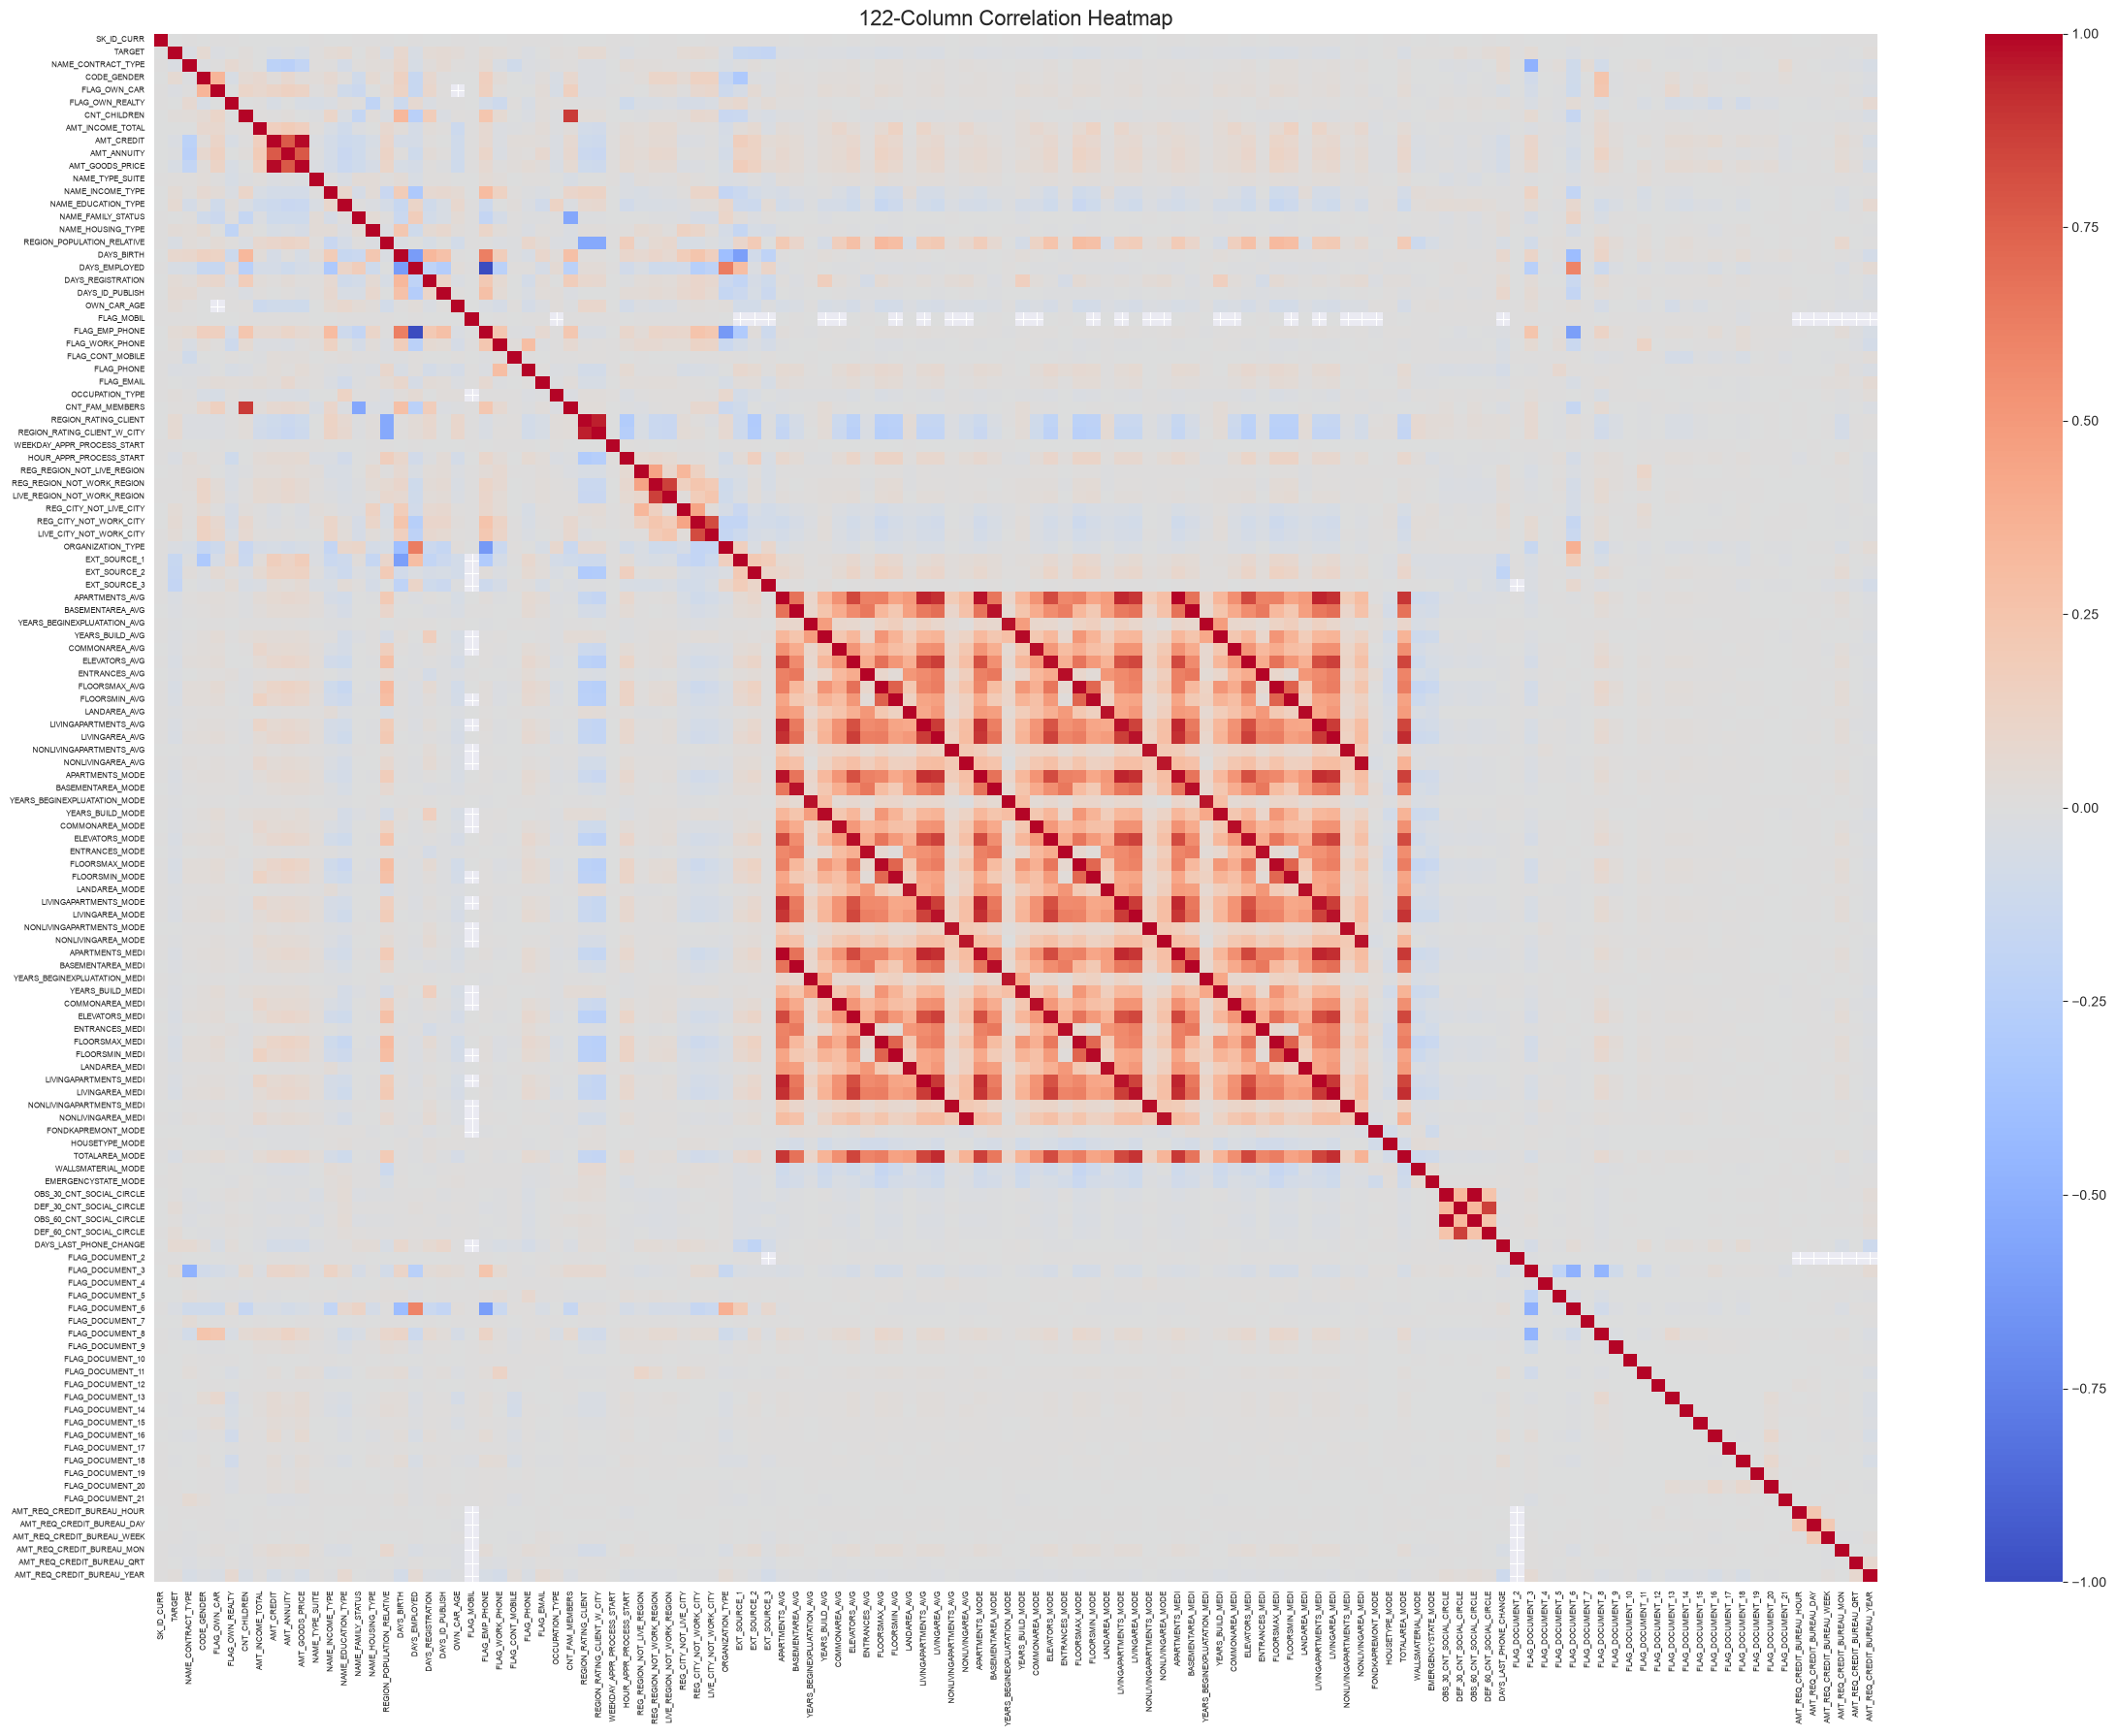

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(24, 18))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    xticklabels=True,
    yticklabels=True,
    vmin=-1, vmax=1
)

plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)

plt.title("122-Column Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
target_corr = df.corrwith(df["TARGET"], numeric_only=True)
target_corr

SK_ID_CURR                   -0.002108
TARGET                        1.000000
NAME_CONTRACT_TYPE           -0.030896
CODE_GENDER                   0.054692
FLAG_OWN_CAR                 -0.021851
                                ...   
AMT_REQ_CREDIT_BUREAU_DAY     0.002704
AMT_REQ_CREDIT_BUREAU_WEEK    0.000788
AMT_REQ_CREDIT_BUREAU_MON    -0.012462
AMT_REQ_CREDIT_BUREAU_QRT    -0.002022
AMT_REQ_CREDIT_BUREAU_YEAR    0.019930
Length: 122, dtype: float64

In [17]:
absolute_corr = target_corr.abs()
absolute_corr

SK_ID_CURR                    0.002108
TARGET                        1.000000
NAME_CONTRACT_TYPE            0.030896
CODE_GENDER                   0.054692
FLAG_OWN_CAR                  0.021851
                                ...   
AMT_REQ_CREDIT_BUREAU_DAY     0.002704
AMT_REQ_CREDIT_BUREAU_WEEK    0.000788
AMT_REQ_CREDIT_BUREAU_MON     0.012462
AMT_REQ_CREDIT_BUREAU_QRT     0.002022
AMT_REQ_CREDIT_BUREAU_YEAR    0.019930
Length: 122, dtype: float64

In [18]:
threshold = 0.01
weak_features = absolute_corr[absolute_corr < threshold].index.tolist()
weak_features

['SK_ID_CURR',
 'FLAG_OWN_REALTY',
 'AMT_INCOME_TOTAL',
 'NAME_TYPE_SUITE',
 'NAME_FAMILY_STATUS',
 'FLAG_MOBIL',
 'FLAG_CONT_MOBILE',
 'FLAG_EMAIL',
 'CNT_FAM_MEMBERS',
 'WEEKDAY_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'YEARS_BEGINEXPLUATATION_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'YEARS_BEGINEXPLUATATION_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'FONDKAPREMONT_MODE',
 'OBS_30_CNT_SOCIAL_CIRCLE',
 'OBS_60_CNT_SOCIAL_CIRCLE',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_B

In [19]:
len(weak_features)

42

In [20]:
df_clean = df.drop(columns = weak_features)
df_clean.head(5)

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,CNT_CHILDREN,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,...,EMERGENCYSTATE_MODE,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_3,FLAG_DOCUMENT_6,FLAG_DOCUMENT_13,FLAG_DOCUMENT_16,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,0.0,1.0,0.0,0,406597.5,24700.5,351000.0,7.0,4.0,...,0.0,2.0,2.0,-1134.0,1,0,0,0,0.0,1.0
1,0,0.0,0.0,0.0,0,1293502.5,35698.5,1129500.0,4.0,1.0,...,0.0,0.0,0.0,-828.0,1,0,0,0,0.0,0.0
2,0,1.0,1.0,1.0,0,135000.0,6750.0,135000.0,7.0,4.0,...,NaN,0.0,0.0,-815.0,0,0,0,0,0.0,0.0
3,0,0.0,0.0,0.0,0,312682.5,29686.5,297000.0,7.0,4.0,...,NaN,0.0,0.0,-617.0,1,0,0,0,NaN,NaN
4,0,0.0,1.0,0.0,0,513000.0,21865.5,513000.0,7.0,4.0,...,NaN,0.0,0.0,-1106.0,0,0,0,0,0.0,0.0


In [21]:
missing_values_columns = df_clean.isna().sum().sort_values(ascending=False)
missing_values_columns

COMMONAREA_AVG             214865
COMMONAREA_MODE            214865
COMMONAREA_MEDI            214865
LIVINGAPARTMENTS_AVG       210199
LIVINGAPARTMENTS_MODE      210199
                            ...  
REG_CITY_NOT_LIVE_CITY          0
REG_CITY_NOT_WORK_CITY          0
LIVE_CITY_NOT_WORK_CITY         0
ORGANIZATION_TYPE               0
TARGET                          0
Length: 80, dtype: int64

In [22]:
missing_values_columns[missing_values_columns > 1]

COMMONAREA_AVG                214865
COMMONAREA_MODE               214865
COMMONAREA_MEDI               214865
LIVINGAPARTMENTS_AVG          210199
LIVINGAPARTMENTS_MODE         210199
LIVINGAPARTMENTS_MEDI         210199
FLOORSMIN_MODE                208642
FLOORSMIN_MEDI                208642
FLOORSMIN_AVG                 208642
YEARS_BUILD_AVG               204488
YEARS_BUILD_MODE              204488
YEARS_BUILD_MEDI              204488
OWN_CAR_AGE                   202929
LANDAREA_MEDI                 182590
LANDAREA_MODE                 182590
LANDAREA_AVG                  182590
BASEMENTAREA_AVG              179943
BASEMENTAREA_MEDI             179943
BASEMENTAREA_MODE             179943
EXT_SOURCE_1                  173378
NONLIVINGAREA_MEDI            169682
NONLIVINGAREA_MODE            169682
NONLIVINGAREA_AVG             169682
ELEVATORS_MODE                163891
ELEVATORS_MEDI                163891
ELEVATORS_AVG                 163891
WALLSMATERIAL_MODE            156341
A

In [23]:
X = df.iloc[:, 2:]
y = df.iloc[:, 1:2]

In [24]:
stats = X.describe()
threshold_for_larger = 2
larger_values_summary = stats.loc["max"].sort_values(ascending = False)
larger_value_columns = larger_values_summary[larger_values_summary >= threshold_for_larger]
larger_value_columns

AMT_INCOME_TOTAL               117000000.0
AMT_CREDIT                       4050000.0
AMT_GOODS_PRICE                  4050000.0
DAYS_EMPLOYED                     365243.0
AMT_ANNUITY                       258025.5
OBS_30_CNT_SOCIAL_CIRCLE             348.0
OBS_60_CNT_SOCIAL_CIRCLE             344.0
AMT_REQ_CREDIT_BUREAU_QRT            261.0
OWN_CAR_AGE                           91.0
ORGANIZATION_TYPE                     57.0
DEF_30_CNT_SOCIAL_CIRCLE              34.0
AMT_REQ_CREDIT_BUREAU_MON             27.0
AMT_REQ_CREDIT_BUREAU_YEAR            25.0
DEF_60_CNT_SOCIAL_CIRCLE              24.0
HOUR_APPR_PROCESS_START               23.0
CNT_FAM_MEMBERS                       20.0
CNT_CHILDREN                          19.0
OCCUPATION_TYPE                       17.0
AMT_REQ_CREDIT_BUREAU_DAY              9.0
AMT_REQ_CREDIT_BUREAU_WEEK             8.0
NAME_INCOME_TYPE                       7.0
NAME_TYPE_SUITE                        6.0
WALLSMATERIAL_MODE                     6.0
WEEKDAY_APP

In [25]:
larger_values_for_mean_impute = larger_values_summary[larger_values_summary >= 17]
larger_values_for_mean_impute

AMT_INCOME_TOTAL              117000000.0
AMT_CREDIT                      4050000.0
AMT_GOODS_PRICE                 4050000.0
DAYS_EMPLOYED                    365243.0
AMT_ANNUITY                      258025.5
OBS_30_CNT_SOCIAL_CIRCLE            348.0
OBS_60_CNT_SOCIAL_CIRCLE            344.0
AMT_REQ_CREDIT_BUREAU_QRT           261.0
OWN_CAR_AGE                          91.0
ORGANIZATION_TYPE                    57.0
DEF_30_CNT_SOCIAL_CIRCLE             34.0
AMT_REQ_CREDIT_BUREAU_MON            27.0
AMT_REQ_CREDIT_BUREAU_YEAR           25.0
DEF_60_CNT_SOCIAL_CIRCLE             24.0
HOUR_APPR_PROCESS_START              23.0
CNT_FAM_MEMBERS                      20.0
CNT_CHILDREN                         19.0
OCCUPATION_TYPE                      17.0
Name: max, dtype: float64

In [26]:
larger_values_for_most_frequent_impute = larger_values_summary[larger_values_summary < 17]
larger_values_for_most_frequent_impute

AMT_REQ_CREDIT_BUREAU_DAY        9.000000
AMT_REQ_CREDIT_BUREAU_WEEK       8.000000
NAME_INCOME_TYPE                 7.000000
NAME_TYPE_SUITE                  6.000000
WALLSMATERIAL_MODE               6.000000
                                 ...     
REGION_POPULATION_RELATIVE       0.072508
DAYS_LAST_PHONE_CHANGE           0.000000
DAYS_ID_PUBLISH                  0.000000
DAYS_REGISTRATION                0.000000
DAYS_BIRTH                   -7489.000000
Name: max, Length: 102, dtype: float64

In [27]:
larger_values_for_mean_impute.index

Index(['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED',
       'AMT_ANNUITY', 'OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
       'AMT_REQ_CREDIT_BUREAU_QRT', 'OWN_CAR_AGE', 'ORGANIZATION_TYPE',
       'DEF_30_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_MON',
       'AMT_REQ_CREDIT_BUREAU_YEAR', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'HOUR_APPR_PROCESS_START', 'CNT_FAM_MEMBERS', 'CNT_CHILDREN',
       'OCCUPATION_TYPE'],
      dtype='str')

In [28]:
SI_MEAN = SimpleImputer(missing_values=np.nan, strategy="mean")
SI_MOST_FREQUENT = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
X_clean = X.copy()
mean_cols = larger_values_for_mean_impute.index
freq_cols = larger_values_for_most_frequent_impute.index

X_clean[mean_cols] = SI_MEAN.fit_transform(X_clean[mean_cols])
X_clean[freq_cols] = SI_MOST_FREQUENT.fit_transform(X_clean[freq_cols])

In [29]:
X_clean.describe()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307511.000000,3.075110e+05,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000
mean,0.095213,0.341669,0.340108,0.693673,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,5.222990,...,0.008130,0.000595,0.000507,0.000335,0.005538,0.006055,0.029723,0.267395,0.265474,1.899974
std,0.293509,0.474297,0.473746,0.460968,0.722121,2.371231e+05,4.024908e+05,14493.454517,3.692794e+05,1.772626,...,0.089798,0.024387,0.022518,0.018299,0.078014,0.103037,0.190728,0.851923,0.738507,1.738528
min,0.000000,0.000000,0.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.899974
75%,0.000000,1.000000,1.000000,1.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.267395,0.265474,3.000000
max,1.000000,2.000000,1.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,6.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [30]:
X_clean.head(5)

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0.0,1.0,0.0,1.0,0.0,202500.0,406597.5,24700.5,351000.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,1.000000
1,0.0,0.0,0.0,0.0,0.0,270000.0,1293502.5,35698.5,1129500.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
2,1.0,1.0,1.0,1.0,0.0,67500.0,135000.0,6750.0,135000.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,0.0,0.0,0.0,1.0,0.0,135000.0,312682.5,29686.5,297000.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.267395,0.265474,1.899974
4,0.0,1.0,0.0,1.0,0.0,121500.0,513000.0,21865.5,513000.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [31]:
SC = StandardScaler()
X_clean[larger_value_columns.index] = SC.fit_transform(X_clean[larger_value_columns.index])

In [32]:
X_clean.describe()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,3.075110e+05,307511.000000,307511.000000,3.075110e+05,3.075110e+05,3.075110e+05,3.075110e+05,3.075110e+05,3.075110e+05,...,307511.000000,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,3.075110e+05,3.075110e+05,3.075110e+05,3.075110e+05
mean,0.095213,-2.310625e-18,0.340108,0.693673,-4.815343e-17,-1.229253e-17,-4.545000e-17,4.713676e-17,3.870298e-17,-4.676706e-17,...,0.008130,0.000595,0.000507,0.000335,-8.503102e-18,1.476490e-17,-7.394001e-19,-3.715486e-17,4.602766e-17,-1.375284e-16
std,0.293509,1.000002e+00,0.473746,0.460968,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,...,0.089798,0.024387,0.022518,0.018299,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,0.000000,-7.203700e-01,0.000000,0.000000,-5.775378e-01,-6.036870e-01,-1.376496e+00,-1.758940e+00,-1.348293e+00,-2.946475e+00,...,0.000000,0.000000,0.000000,0.000000,-7.098743e-02,-5.876598e-02,-1.558375e-01,-3.138730e-01,-3.594746e-01,-1.092866e+00
25%,0.000000,-7.203700e-01,0.000000,0.000000,-5.775378e-01,-2.374210e-01,-8.174760e-01,-7.303015e-01,-8.121132e-01,4.383388e-01,...,0.000000,0.000000,0.000000,0.000000,-7.098743e-02,-5.876598e-02,-1.558375e-01,-3.138730e-01,-3.594746e-01,-5.176655e-01
50%,0.000000,-7.203700e-01,0.000000,1.000000,-5.775378e-01,-9.129414e-02,-2.124151e-01,-1.521775e-01,-2.393752e-01,4.383388e-01,...,0.000000,0.000000,0.000000,0.000000,-7.098743e-02,-5.876598e-02,-1.558375e-01,-3.138730e-01,-3.594746e-01,-1.277201e-16
75%,0.000000,1.388015e+00,1.000000,1.000000,8.072731e-01,1.421293e-01,5.208178e-01,5.166083e-01,3.821064e-01,4.383388e-01,...,0.000000,0.000000,0.000000,0.000000,-7.098743e-02,-5.876598e-02,-1.558375e-01,-6.515991e-17,0.000000e+00,6.327349e-01
max,1.000000,3.496400e+00,1.000000,1.000000,2.573387e+01,4.927034e+02,8.574059e+00,1.593252e+01,9.509356e+00,4.383388e-01,...,1.000000,1.000000,1.000000,1.000000,5.120186e+01,8.728854e+01,4.178879e+01,3.137918e+01,3.530567e+02,1.328714e+01


In [33]:
X_clean.head()

,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,0.0,1.388015,0.0,1.0,-0.577538,0.142129,-0.478095,-0.166149,-0.507465,0.438339,...,0.0,0.0,0.0,0.0,-0.070987,-0.058766,-0.155837,-3.138730e-01,-0.359475,-5.176655e-01
1,0.0,-0.720370,0.0,0.0,-0.577538,0.426792,1.725450,0.592677,1.600698,-2.382339,...,0.0,0.0,0.0,0.0,-0.070987,-0.058766,-0.155837,-3.138730e-01,-0.359475,-1.092866e+00
2,1.0,1.388015,1.0,1.0,-0.577538,-0.427196,-1.152888,-1.404676,-1.092389,0.438339,...,0.0,0.0,0.0,0.0,-0.070987,-0.058766,-0.155837,-3.138730e-01,-0.359475,-1.092866e+00
3,0.0,-0.720370,0.0,1.0,-0.577538,-0.142533,-0.711430,0.177869,-0.653696,0.438339,...,0.0,0.0,0.0,0.0,-0.070987,-0.058766,-0.155837,-6.515991e-17,0.000000,-1.277201e-16
4,0.0,1.388015,0.0,1.0,-0.577538,-0.199466,-0.213734,-0.361755,-0.068772,0.438339,...,0.0,0.0,0.0,0.0,-0.070987,-0.058766,-0.155837,-3.138730e-01,-0.359475,-1.092866e+00


In [34]:
y.head(5)

,TARGET
0,1
1,0
2,0
3,0
4,0


In [35]:
missing_values_columns = X_clean.isna().sum().sort_values(ascending=False)
missing_values_columns[missing_values_columns > 1]

Series([], dtype: int64)

In [36]:
len(X_clean)

307511

In [37]:
len(X_clean.columns)

120

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

In [64]:
model = LogisticRegression(class_weight="balanced", solver="saga", max_iter=1000)
model.fit(X_train, y_train.values.ravel())

/Users/deepakkumarbehera/Downloads/WORKSPACE/LPU-Summer internship-Assignment/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'saga'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; mu

In [65]:
y_pred = model.predict(X_test)

In [66]:
accurcy = accuracy_score(y_test, y_pred)
accurcy

0.6902102336471392

In [67]:
confusion_matrix(y_test, y_pred)

array([[40106, 16448],
       [ 2605,  2344]])

In [68]:
!pip install Xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 13.6 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [72]:
import xgboost as xgb
num_negatives = float((y_train.values.ravel() == 0).sum())
num_positives = float((y_train.values.ravel() == 1).sum())
imbalance_ratio = num_negatives / num_positives

print(f"Calculated imbalance ratio: {imbalance_ratio:.4f}")

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    random_state=42,
    eval_metric='logloss'
)

# 1. Fit using the scaled training data
xgb_model.fit(X_train, y_train.values.ravel())

# 2. FIXED: Predict using xgb_model and the scaled test data
test_predictions = xgb_model.predict(X_test)

print("--- XGBoost Confusion Matrix ---")
print(confusion_matrix(y_test, test_predictions))

print("\n--- Classification Report ---")
print(classification_report(y_test, test_predictions))

Calculated imbalance ratio: 11.3771
--- XGBoost Confusion Matrix ---
[[41471 15083]
 [ 1779  3170]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     56554
           1       0.17      0.64      0.27      4949

    accuracy                           0.73     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.73      0.79     61503



In [94]:
test_probabilities = xgb_model.predict_proba(X_test)[:, 1]

custom_threshold = 0.65
adjusted_predictions = (test_probabilities >= custom_threshold).astype(int)

# 3. Evaluate the new balanced matrix
print(f"--- Confusion Matrix at Threshold {custom_threshold} ---")
print(confusion_matrix(y_test, adjusted_predictions))

--- Confusion Matrix at Threshold 0.65 ---
[[50125  6429]
 [ 2910  2039]]


In [96]:
validation_data = pd.read_csv("../DATASETS/application_test.csv")
validation_data

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,3.0,1.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,2.0


In [143]:
feature_list = xgb_model.feature_names_in_.tolist()
validation_feature = validation_data.columns.tolist()
submission_ids = validation_data["SK_ID_CURR"]
validation_feature.remove("SK_ID_CURR")

In [144]:
len(validation_feature) == len(feature_list)

True

In [145]:
validation_feature == feature_list

True

In [146]:
X_val = validation_data.drop(columns=["SK_ID_CURR"])

In [147]:
X_val.columns.tolist() == feature_list

True

In [148]:
categorical_cols_val = X_val.select_dtypes(include=['object', 'string']).columns
X_val[categorical_cols_val] = OE.transform(X_val[categorical_cols_val])

In [149]:
X_val.columns.tolist() == feature_list

True

In [150]:
mean_cols = larger_values_for_mean_impute.index.intersection(X_val.columns)
X_val[mean_cols] = SI_MEAN.transform(X_val[mean_cols])

freq_cols = larger_values_for_most_frequent_impute.index.intersection(X_val.columns)
X_val[freq_cols] = SI_MOST_FREQUENT.transform(X_val[freq_cols])

In [151]:
X_val.columns.tolist() == feature_list

True

In [152]:
X_val[larger_value_columns.index] = SC.transform(X_val[larger_value_columns.index])

In [153]:
model_expected_features = xgb_model.feature_names_in_

X_val = X_val[model_expected_features]

In [154]:
X_val.columns.tolist() == feature_list

True

In [155]:
predictions = xgb_model.predict(X_val)

In [156]:
predictions

array([0, 1, 0, ..., 0, 1, 1], shape=(48744,))

In [157]:
probabilities = xgb_model.predict_proba(X_val)[:, 1]
predictions = (probabilities >= 0.65).astype(int)
predictions

array([0, 0, 0, ..., 0, 0, 1], shape=(48744,))

In [160]:
submission_df_probas = pd.DataFrame({
    "SK_ID_CURR": submission_ids,
    "TARGET": probabilities  # Raw decimal risk scores
})
submission_df_probas.to_csv("/Users/deepakkumarbehera/Downloads/WORKSPACE/LPU-Summer internship-Assignment/DATASETS/submission_xgb_probabilities.csv", index=False)

In [161]:
resultz_df = pd.read_csv("../DATASETS/submission_xgb_probabilities.csv")
resultz_df.shape

(48744, 2)

In [162]:
resultz_df.head(5)

,SK_ID_CURR,TARGET
0,100001,0.187499
1,100005,0.571198
2,100013,0.155380
3,100028,0.303708
4,100038,0.628724


In [163]:
chosen_threshold = 0.65
binary_predictions = (probabilities >= chosen_threshold).astype(int)

submission_df_binary = pd.DataFrame({
    "SK_ID_CURR": validation_data["SK_ID_CURR"],
    "TARGET": binary_predictions
})

submission_df_binary.to_csv("../DATASETS/submission_xgb_probabilities_0_and_1.csv", index=False)